# **602: Principles of Data Science**

# Project 2: Data Pre-Processing

## **2. Research Question**

Can we predict whether a startup will succeed (acquired/IPO) or fail (closed) based on its early characteristics such as funding rounds, total investment, relationships, and milestones?

**Why it’s interesting:**

Investors face huge risks - most startups fail, but predicting success factors could guide better investment decisions.

Personally, I am interested in tech and entrepreneurship, so studying startup success is motivating for me.

## **3. Population**

Population in our case: Global startups founded in the last two decades across various industries (tech, healthcare, finance, etc.).

**Sample in dataset**: 923 startups with information on funding, milestones, investors, and status 48 other features.

## **4. Variables**  

### Independent Variables
- **`funding_rounds`** — Number of funding rounds a startup has gone through  
- **`funding_total_usd`** — Total funding amount raised (in USD)  
- **`relationships`** — Number of relationships/partnerships of the startup  
- **`milestones`** — Number of achievements such as product launches, partnerships, etc.  
- **`age_first_funding_year`**, **`age_last_funding_year`** — Timing of first and last funding events  
- **`industry_type`** — Type of industry the startup belongs to  
- **`state_code`** — Geographical location (state) of the startup  
- **`has_VC`**, **`has_angel`**, **`has_roundA`**, **`has_roundB`**, etc. — Indicators for whether the startup received specific funding types  

### Dependent Variable
- **`status`** — Categorical variable indicating the outcome:  
  - **Acquired/IPO** → Success  
  - **Closed** → Failure  

### Confounding Variables
In this dataset, potential confounders include:

- **Geography (`state_code`, `is_CA`, `is_NY`, etc.)**  
  Startups in CA/NY tend to have more access to investors, mentors, and markets. This geographic advantage could make it look like funding alone drives success, when location also matters.

- **Relationships (`relationships`)**  
  Strong networks can boost a startup’s success chances, but this may overlap with geography (startups in SF naturally build more relationships).

---

### How I will deal with them
- Remove duplicate or overlapping features for example, keep either `state_code` or `is_CA`, not both.  
- Treat **funding type** variables separately from **funding amount** to avoid redundancy.
- With more resources, I would integrate, some confounders like **founder experience** that are not available in this dataset, which I believe strongly influences a startup success.


## **5. Hypothesis**

**Statement:**  

 Startups with more funding rounds, higher total funding, and venture capital involvement are more likely to succeed (IPO/Acquisition) than those without such characteristics.

**Hypothesis:**  
- **Null Hypothesis (H₀):** There is no relationship between the features (funding, industry, location, etc.) and the success of a startup. Startup success is purely random.  
- **Alternative Hypothesis (H₁):** Certain factors (such as funding rounds, total funding, industry type, and geography) are associated with a higher likelihood of startup success.  

**Expected Outcome:**  
- Startups with more funding rounds and higher funding amounts are more likely to succeed.  
- Startups in tech-heavy industries (e.g., software, web, mobile) and in states like California or New York will have higher success rates.  
- Startups backed by venture capital or angel investors will show better performance compared to those without such backing.

## **6. Data Collection Plan**
- **Source:** Public startup dataset (Kaggle, Crunchbase export).  
- **Representativeness:** Ensure the sample covers a mix of industries, regions, and funding sizes.  
- **Method:** For this project, we’ll use an existing Kaggle dataset (`startup data.csv`).
- More details about dataset is given below:

## **7. Dataset Details**  
- **Dataset:** Startup Success Dataset  
- **Size:** 923 startups, 48 features  
- **Format:** CSV
- **Why Interesting?** Allows us to analyze what drives startup success/failure, tying directly into tech + business interests.  
- **Source:** [Link to the Kaggle](https://www.kaggle.com/datasets/manishkc06/startup-success-prediction/)  
- Dataset is 5 years old which was created in 2020.  


### Ensuring Representativeness of the Sample

To ensure that the dataset represents the broader startup population:  

- **Diversity of Industries:** The dataset includes startups across multiple categories (software, biotech, mobile, e-commerce, etc.), reducing bias toward any one sector.  
- **Geographic Spread:** Variables like `state_code` and `city` help capture startups across different regions (e.g., CA, NY, TX, and others).

- **Variety of Funding Stages:** The dataset covers multiple funding types (VC, angel, seed, Series A–D), which helps represent startups at different life cycle stages.  
- **Large Sample Size:** With ~900 startups and many features, the dataset provides a sufficient base to capture trends while minimizing the risk of sampling error.  


## Dataset Choice & Description

**Chosen Dataset**: `startups_dataset.csv` (923 startups, 49 columns)

### Why This Dataset?

- **Balanced**: The dataset is large enough to support meaningful statistical analysis, yet small enough to allow for quick analysis.
- **Feature Rich**: It includes a wide variety of variables—financial, temporal, and categorical—enabling deep exploratory data analysis and feature engineering.
- The dataset aligns with my interest in technology, startups, and understanding what drives business success.

### Contents

The dataset includes:

- Startup metadata (e.g., name, founding year)
- Funding details (e.g., funding rounds, total raised)
- Milestones achieved
- Investor types
- Final outcome/status of the startup

### Target Variable

- `status`: Categorized into:
  - **Success**: `acquired`, `IPO`
  - **Failure**: `closed`

### Dataset Timeframe

The data spans multiple years, approximately from the early 2000s to the 2010s. (Exact range to be determined during data exploration.)

---

# **8. Importing and printing the first 5 columns of data**

In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Load dataset
# Link to the dataset: https://drive.google.com/file/d/1Mz1xPy61rC35rdIxis9a9ojP-0rgMaYC/view?usp=sharing
file_path = '/content/drive/My Drive/startups_dataset.csv'
df = pd.read_csv(file_path)

# df = pd.read_csv("startups_dataset.csv")

# Printing first 5 rows
df.head()

Mounted at /content/drive


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


---

# **Project 2**

## Step 2

In [2]:
df_copy = df.copy()
# Shape
shape = df_copy.shape
print('Shape of the data:', shape)

# Data types
print('\nData types in the data:')
print(df_copy.dtypes)

# List columns / variables
print('\nColumns (total {}):'.format(len(df_copy.columns)))
print(list(df_copy.columns))

# Unique elements per column
print('\nNumber of unique elements per column (including NaN):')
print(df_copy.nunique(dropna=False))

# Descriptive statistics
print('\nDescriptive statistics — numeric columns:')
display(df_copy.describe(include=[np.number]).transpose())

print('\nDescriptive statistics — non-numeric columns (counts / top):')
display(df_copy.describe(include=[object]).transpose())

Shape of the data: (923, 49)

Data types in the data:
Unnamed: 0                    int64
state_code                   object
latitude                    float64
longitude                   float64
zip_code                     object
id                           object
city                         object
Unnamed: 6                   object
name                         object
labels                        int64
founded_at                   object
closed_at                    object
first_funding_at             object
last_funding_at              object
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
state_code.1                 object
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX     

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,923.0,5.722979e+02,3.335854e+02,1.000000,2.835000e+02,5.770000e+02,8.665000e+02,1.153000e+03
latitude,923.0,3.851744e+01,3.741497e+00,25.752358,3.738887e+01,3.777928e+01,4.073065e+01,5.933523e+01
longitude,923.0,-1.035392e+02,2.239417e+01,-122.756956,-1.221987e+02,-1.183740e+02,-7.721473e+01,1.805712e+01
labels,923.0,6.468039e-01,4.782221e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
age_first_funding_year,923.0,2.235630e+00,2.510449e+00,-9.046600,5.767000e-01,1.446600e+00,3.575350e+00,2.189590e+01
age_last_funding_year,923.0,3.931456e+00,2.967910e+00,-9.046600,1.669850e+00,3.528800e+00,5.560250e+00,2.189590e+01
age_first_milestone_year,771.0,3.055353e+00,2.977057e+00,-14.169900,1.000000e+00,2.520500e+00,4.686300e+00,2.468490e+01
age_last_milestone_year,771.0,4.754423e+00,3.212107e+00,-7.005500,2.411000e+00,4.476700e+00,6.753400e+00,2.468490e+01
relationships,923.0,7.710726e+00,7.265776e+00,0.000000,3.000000e+00,5.000000e+00,1.000000e+01,6.300000e+01
funding_rounds,923.0,2.310943e+00,1.390922e+00,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,1.000000e+01



Descriptive statistics — non-numeric columns (counts / top):


,count,unique,top,freq
state_code,923,35,CA,488
zip_code,923,382,94107,30
id,923,922,c:28482,2
city,923,221,San Francisco,128
Unnamed: 6,430,252,San Francisco CA 94105,12
name,923,922,Redwood Systems,2
founded_at,923,217,1/1/2003,55
closed_at,335,202,6/1/2013,25
first_funding_at,923,585,1/1/2008,18
last_funding_at,923,680,1/1/2008,11


## Step 3 — Specific Data Needs for This Project

For this project, only a single dataset (`startups_dataset.csv`) is used.  
There are **no additional datasets** that need to be merged or joined.

Since all relevant attributes — such as company identifiers, location details and funding information — are already contained within this single file, the dataset is **self-contained** and sufficient for the required cleaning and analysis.
Therefore, **no merging operations are necessary**.

## Step 4 — Look for potential issues in the data

We will check duplicates, missing/null values, type inconsistencies, problematic misspellings, and outliers detected using the Z-score method (|Z| > 3).

In [3]:
#a) Duplicates
dup_count = int(df_copy.duplicated().sum())
print('Duplicate rows (exact across all columns):', dup_count)
if dup_count>0:
    display(df_copy[df_copy.duplicated(keep=False)].head(5))

#b) Missing / null values
missing_counts = df_copy.isnull().sum()
missing_percent = (missing_counts / len(df_copy)) * 100
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_percent': missing_percent}).sort_values('missing_count', ascending=False)
print('\nColumns with missing values (count and percent):')
display(missing_df[missing_df['missing_count']>0])

total_missing = int(missing_counts.sum())
print('\nTotal missing cells:', total_missing)
print('Proportion of missing cells:', total_missing / (df_copy.shape[0]*df_copy.shape[1]))

# Check for type inconsistencies in object columns
object_cols = df_copy.select_dtypes(include='object').columns
coercion_report = {}

for col in object_cols:
    # Checking for convertion of text columns to numeric
    coerced = pd.to_numeric(df_copy[col], errors='coerce')
    non_convertible = ((coerced.isnull()) & (df_copy[col].notnull())).sum()
    if non_convertible > 0:
        coercion_report[col] = non_convertible

print("Columns with potential type inconsistencies:")
print(coercion_report if coercion_report else "No type inconsistencies found.")


print('\nColumns with non-convertible entries when coercing to numeric (object cols):')
if coercion_report:
    display(pd.Series(coercion_report).sort_values(ascending=False).head(30))
else:
    print('None detected.')

#d) Problematic misspellings/mistypings: value_counts for low-cardinality categorical columns (<=50 unique)
print('\nLow-cardinality categorical columns (<=50 unique) and their value counts:')
low_card_cols = [c for c in object_cols if df_copy[c].nunique(dropna=False) <= 50]
for c in low_card_cols:
    print(f'\nColumn: {c} (unique: {df_copy[c].nunique(dropna=False)})')
    print(df_copy[c].value_counts(dropna=False).head(50))

#e) Outliers detection using Z-score (|Z| > 3) for numeric columns
numeric_cols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {}
for c in numeric_cols:
    col_vals = df_copy[c].dropna()
    if col_vals.shape[0] < 2 or col_vals.std(ddof=0) == 0:
        outlier_counts[c] = 0
        continue
    z = (col_vals - col_vals.mean())/col_vals.std(ddof=0)
    outlier_counts[c] = int((z.abs() > 3).sum())

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print('\nOutlier counts per numeric column (|Z| > 3):')
display(outlier_series[outlier_series>0])

# Show top outlier rows for up to top 3 numeric columns with outliers
top_outlier_cols = list(outlier_series[outlier_series>0].index[:3])
for col in top_outlier_cols:
    print(f'\nTop outlier rows for column: {col}')
    col_series = df_copy[col]
    if col_series.std(ddof=0)==0 or col_series.dropna().shape[0]<2:
        print('Not enough variation.')
        continue
    z_all = (col_series - col_series.mean())/col_series.std(ddof=0)
    mask = z_all.abs() > 3
    display(df_copy.loc[mask].sort_values(by=col, ascending=False).head(10))

Duplicate rows (exact across all columns): 0

Columns with missing values (count and percent):


,missing_count,missing_percent
closed_at,588,63.705309
Unnamed: 6,493,53.412784
age_first_milestone_year,152,16.468039
age_last_milestone_year,152,16.468039
state_code.1,1,0.108342



Total missing cells: 1386
Proportion of missing cells: 0.030645410927101067
Columns with potential type inconsistencies:
{'state_code': np.int64(923), 'zip_code': np.int64(24), 'id': np.int64(923), 'city': np.int64(923), 'Unnamed: 6': np.int64(430), 'name': np.int64(923), 'founded_at': np.int64(923), 'closed_at': np.int64(335), 'first_funding_at': np.int64(923), 'last_funding_at': np.int64(923), 'state_code.1': np.int64(922), 'category_code': np.int64(923), 'object_id': np.int64(923), 'status': np.int64(923)}

Columns with non-convertible entries when coercing to numeric (object cols):


,0
state_code,923
id,923
name,923
city,923
first_funding_at,923
founded_at,923
status,923
object_id,923
last_funding_at,923
category_code,923



Low-cardinality categorical columns (<=50 unique) and their value counts:

Column: state_code (unique: 35)
state_code
CA    488
NY    106
MA     83
WA     42
TX     42
CO     19
IL     18
PA     17
VA     13
GA     11
NC      7
OR      7
NJ      7
MD      7
FL      6
OH      6
MN      5
CT      4
DC      4
UT      3
TN      3
RI      3
MI      3
KY      2
ME      2
NH      2
MO      2
IN      2
NV      2
AZ      2
WV      1
NM      1
ID      1
AR      1
WI      1
Name: count, dtype: int64

Column: state_code.1 (unique: 36)
state_code.1
CA     487
NY     106
MA      83
WA      42
TX      42
CO      19
IL      18
PA      17
VA      13
GA      11
NJ       7
NC       7
OR       7
MD       7
OH       6
FL       6
MN       5
DC       4
CT       4
TN       3
UT       3
RI       3
MI       3
KY       2
NV       2
NH       2
MO       2
ME       2
AZ       2
IN       2
WV       1
NM       1
NaN      1
ID       1
AR       1
WI       1
Name: count, dtype: int64

Column: category_code (unique: 35)

...

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
7,875,CA,38.057107,-122.513742,94901,c:5192,San Rafael,NaN,ClairMail,1,...,c:5192,0,0,1,1,0,1,3.5000,1,acquired
8,16,MA,42.712207,-73.203599,1267,c:1043,Williamstown,Williamstown MA 1267,VoodooVox,1,...,c:1043,1,0,1,0,0,1,4.0000,1,acquired
16,235,CA,37.396283,-122.105531,94022,c:16770,Los Altos,NaN,QSecure,0,...,c:16770,1,0,1,1,1,1,3.5000,1,closed
17,25,CA,37.590339,-122.341715,94010,c:107,Burlingame,NaN,MeeVee,1,...,c:107,0,0,1,1,1,1,3.5000,1,acquired
49,403,CA,37.560781,-122.284114,94404,c:2395,San Mateo,NaN,Fortify Software,1,...,c:2395,0,0,0,0,0,1,2.0000,1,acquired
53,364,MA,42.375640,-71.235800,2451,c:22027,Waltham,Waltham MA 2451,Colubris Networks,1,...,c:22027,1,0,0,0,0,1,5.0000,1,acquired
54,31,CA,37.787084,-122.403805,94103,c:109,San Francisco,NaN,Mashery,1,...,c:109,1,1,1,1,1,1,5.0000,1,acquired
73,245,CA,37.779026,-122.401840,94103,c:170,San Francisco,NaN,adBrite,1,...,c:170,0,0,1,1,1,1,1.6667,1,acquired



Top outlier rows for column: is_MA


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
8,16,MA,42.712207,-73.203599,1267,c:1043,Williamstown,Williamstown MA 1267,VoodooVox,1,...,c:1043,1,0,1,0,0,1,4.0000,1,acquired
47,593,MA,42.375100,-71.105616,2139,c:33507,Cambridge,Cambridge MA 2139,Performable,1,...,c:33507,0,0,1,0,0,0,1.0000,1,acquired
51,847,MA,42.360253,-71.058291,2210,c:49815,Boston,Boston MA 2210,AisleBuyer,1,...,c:49815,0,0,0,0,0,0,1.0000,1,acquired
53,364,MA,42.375640,-71.235800,2451,c:22027,Waltham,Waltham MA 2451,Colubris Networks,1,...,c:22027,1,0,0,0,0,1,5.0000,1,acquired
60,617,MA,42.546483,-71.173667,1887,c:35157,Wilmington,Wilmington MA 1887,Viacor,0,...,c:35157,0,0,0,1,0,0,2.0000,1,closed
64,396,MA,42.360253,-71.058291,02111-1720,c:23533,Boston,Boston MA 02111-1720,CardStar,1,...,c:23533,0,0,1,0,0,0,3.0000,1,acquired
79,555,MA,42.375100,-71.105616,2138,c:31514,Cambridge,Cambridge MA 2138,AccelGolf,0,...,c:31514,1,1,0,0,0,0,1.0000,1,closed
120,841,MA,42.387597,-71.099497,2143,c:49236,Somerville,Somerville MA 2143,Loudcaster,0,...,c:49236,0,1,0,0,0,0,1.0000,1,closed
125,704,MA,42.375640,-71.235800,2451,c:40324,Waltham,Waltham MA 2451,Artisan Pharma,1,...,c:40324,0,0,1,1,1,0,4.6667,1,acquired
137,430,MA,42.363466,-71.078664,2142,c:25324,Cambridge,NaN,Taligen Therapeutics,1,...,c:25324,0,0,1,1,0,0,3.5000,1,acquired



Top outlier rows for column: is_mobile


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
8,16,MA,42.712207,-73.203599,1267,c:1043,Williamstown,Williamstown MA 1267,VoodooVox,1,...,c:1043,1,0,1,0,0,1,4.00,1,acquired
10,685,CA,37.442988,-122.162413,94025,c:3949,Menlo Park,NaN,Zong,1,...,c:3949,0,0,1,1,0,0,1.00,1,acquired
23,26,CA,37.764395,-122.401024,94103,c:10751,San Francisco,NaN,Pixelpipe,0,...,c:10751,0,1,1,0,0,0,2.00,0,closed
33,145,CA,37.779281,-122.419236,94105,c:150658,San Francisco,San Francisco CA 94105,Karma,1,...,c:150658,1,0,0,0,0,0,5.00,1,acquired
41,139,NH,42.995640,-71.454789,3101,c:149809,Manchester,Manchester NH 3101,Trendslide,1,...,c:149809,0,1,0,0,0,0,1.00,0,acquired
51,847,MA,42.360253,-71.058291,2210,c:49815,Boston,Boston MA 2210,AisleBuyer,1,...,c:49815,0,0,0,0,0,0,1.00,1,acquired
59,950,MO,39.103151,-94.581908,64106,c:5932,Kansas City,NaN,Handmark,1,...,c:5932,0,0,1,1,0,0,4.50,1,acquired
79,555,MA,42.375100,-71.105616,2138,c:31514,Cambridge,Cambridge MA 2138,AccelGolf,0,...,c:31514,1,1,0,0,0,0,1.00,1,closed
80,943,CA,37.779281,-122.419236,94105,c:58944,San Francisco,San Francisco CA 94105,MoPub,1,...,c:58944,0,1,1,1,0,0,2.25,1,acquired
109,316,CT,41.853615,-72.703750,6002,c:19101,Bloomfield,NaN,Pocket Communications Northeast,0,...,c:19101,0,0,1,1,0,0,2.00,1,closed


## Redundant Columns

In [4]:
df_copy[df_copy['id'] == df_copy['object_id']].shape[0]

923

Columns: `id` and `object_id` are redundant as they are representing the same information for all the rows.

## Step 5

Renaming ambiguous columns for clarity.

In [5]:
print('First 15 columns (before renaming):')
print(df_copy.columns.tolist()[:15])

renames = {
    'Unnamed: 0': 'record_id',
    'Unnamed: 6': 'address',
    'id': 'company_id',
    'avg_participants': 'avg_participants_per_milestone'
}

applied_renames = {k:v for k,v in renames.items() if k in df_copy.columns}
df_copy.rename(columns=applied_renames, inplace=True)

print('\nApplied renames:')
if applied_renames:
    for old, new in applied_renames.items():
        print(f'  {old} -> {new}')
else:
    print('  No columns were renamed.')

print('\nFirst 15 columns (after renaming):')
print(df_copy.columns.tolist()[:15])

First 15 columns (before renaming):
['Unnamed: 0', 'state_code', 'latitude', 'longitude', 'zip_code', 'id', 'city', 'Unnamed: 6', 'name', 'labels', 'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at', 'age_first_funding_year']

Applied renames:
  Unnamed: 0 -> record_id
  Unnamed: 6 -> address
  id -> company_id
  avg_participants -> avg_participants_per_milestone

First 15 columns (after renaming):
['record_id', 'state_code', 'latitude', 'longitude', 'zip_code', 'company_id', 'city', 'address', 'name', 'labels', 'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at', 'age_first_funding_year']


## Step 6 — Develop a detailed plan for cleaning

Below is the plan based on the issues observed in Step 4. Implementation will be done in Step 7.

| Issue Type          | Columns                      | Cleaning Technique                          | Reason                    |
| ------------------- | ------------------------------------- | ------------------------------------------- | ------------------------- |
| Missing values      | `Unnamed: 6`, `zip_code`, `city`      | Fill with `"Unknown"` | Prevents model errors     |
| Duplicates          | All columns                           | Remove duplicates                           | Avoid bias                |
| Outliers            | `funding_total_usd`, `funding_rounds` | Cap at 1st and 99th percentiles    | Smooth skewed data        |
| Type mismatch       | `funding_total_usd`                   | Convert to numeric (coerce errors)          | Consistent numeric ops    |
| Inconsistent labels | `status`                              | Standardize to lowercase                    | Ensures category accuracy |
| Irrelevant columns  | e.g. `object_id`, `id`                | Drop since its redundant                           | Simplifies dataset        |


## Step 7 — Clean your data

In [6]:
from scipy.stats.mstats import winsorize

df_copy = df_copy.copy()

clean_log = []
before_shape = df_copy.shape

#1. Remove duplicates
dupes = df_copy.duplicated().sum()
if dupes > 0:
    df_copy.drop_duplicates(inplace=True)
clean_log.append(f"- No duplicates found." if dupes == 0 else f"- Removed {dupes} duplicates.")

#2. Handle missing values for text columns
text_cols = [col for col in df_copy.select_dtypes(include='object').columns if col != 'zip_code']
for col in text_cols:
    missing = df_copy[col].isna().sum()
    if missing > 0:
        df_copy[col] = df_copy[col].fillna('Unknown')
        clean_log.append(f"- Filled {missing} missing in text column {col} with 'Unknown'.")

#3. Handle missing values for numeric columns
numeric_cols = df_copy.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    missing = df_copy[col].isna().sum()
    if missing > 0:
        med = df_copy[col].median()
        df_copy[col] = df_copy[col].fillna(med)
        clean_log.append(f"- Filled {missing} missing in numeric column {col} with median {round(med,4)}.")


#4. Standardize categorical values
for col in df_copy.select_dtypes(include='object').columns:
    df_copy[col] = df_copy[col].astype(str).str.strip().str.lower()
clean_log.append("- Standardized categorical columns.")


#5. Capping outliers in numeric columns
num_cols_for_winsorize = [col for col in df_copy.select_dtypes(include=['float64','int64']).columns if col != 'zip_code']
for col in num_cols_for_winsorize:
    lower, upper = 0, 0
    before = df_copy[col].copy()
    wins = winsorize(df_copy[col], limits=[0.01, 0.01])
    capped_lower = (before < wins).sum()
    capped_upper = (before > wins).sum()

    if capped_lower > 0 or capped_upper > 0:
        df_copy[col] = wins
        clean_log.append(f"- Capping {col}: {capped_lower} lower, {capped_upper} upper capped.")


#6. If numeric-looking object columns exist, try to convert them to numeric data type
object_cols_for_coerce = [col for col in df_copy.select_dtypes(include='object').columns if col != 'zip_code']
for col in object_cols_for_coerce:
    num_like_ratio = df_copy[col].astype(str).str.match(r'^\d+(\.\d+)?$').mean()
    if num_like_ratio > 0.5:
        df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')
        clean_log.append(f"- Coerced mostly-numeric column {col} to numeric.")

#7. Removing Redundant Columns
if 'company_id' in df_copy.columns and 'object_id' in df_copy.columns:
    if (df_copy['company_id'] == df_copy['object_id']).all():
        df_copy.drop(columns='object_id', inplace=True)
        clean_log.append("- Removed redundant 'object_id' column.")

#8. Final missing values and shape summary
remaining_missing = df_copy.isna().sum().sum()
clean_log.append(f"- Remaining missing values after cleaning: {remaining_missing}")
after_shape = df_copy.shape
clean_log.append(f"\nShape after cleaning: {after_shape}")

print("Cleaning actions log:")
print("\n".join(clean_log))

Cleaning actions log:
- No duplicates found.
- Filled 493 missing in text column address with 'Unknown'.
- Filled 588 missing in text column closed_at with 'Unknown'.
- Filled 1 missing in text column state_code.1 with 'Unknown'.
- Filled 152 missing in numeric column age_first_milestone_year with median 2.5205.
- Filled 152 missing in numeric column age_last_milestone_year with median 4.4767.
- Standardized categorical columns.
- Capping record_id: 9 lower, 9 upper capped.
- Capping latitude: 9 lower, 9 upper capped.
- Capping longitude: 9 lower, 9 upper capped.
- Capping age_first_funding_year: 7 lower, 9 upper capped.
- Capping age_last_funding_year: 9 lower, 9 upper capped.
- Capping age_first_milestone_year: 8 lower, 9 upper capped.
- Capping age_last_milestone_year: 9 lower, 9 upper capped.
- Capping relationships: 0 lower, 8 upper capped.
- Capping funding_rounds: 0 lower, 3 upper capped.
- Capping funding_total_usd: 5 lower, 9 upper capped.
- Capping milestones: 0 lower, 7 uppe

## Step 8 — Save cleaned data to a new file

In [7]:
CLEANED_PATH = '/content/startups_dataset_cleaned.csv'
df_copy.to_csv(CLEANED_PATH, index=False)
print('Saved cleaned dataset locally at', CLEANED_PATH)

# # Saving to Google Drive
# CLEANED_DRIVE_PATH = '/content/drive/My Drive/startups_dataset_cleaned.csv'
# df_copy.to_csv(CLEANED_DRIVE_PATH, index=False)
# print('Also saved cleaned dataset to Drive at', CLEANED_DRIVE_PATH)

Saved cleaned dataset locally at /content/startups_dataset_cleaned.csv


## Step 9 — Import the cleaned data file

In [8]:
df_cleaned = pd.read_csv(CLEANED_PATH)
print('Re-import successful. Shape:', df_cleaned.shape)

Re-import successful. Shape: (923, 48)


## Step 10 — The first and last 5 entries of the cleaned Data file

In [9]:
print('First 5 entries: ')
display(df_cleaned.head())

print('\nLast 5 entries: ')
display(df_cleaned.tail())

First 5 entries: 


,record_id,state_code,latitude,longitude,zip_code,company_id,city,address,name,labels,...,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants_per_milestone,is_top500,status
0,1005,ca,42.358880,-71.058096,92101,c:6669,san diego,unknown,bandsintown,1,...,1,0,1,0,0,0,0,1.0000,0,acquired
1,204,ca,37.238916,-121.973718,95032,c:16283,los gatos,unknown,tricipher,1,...,0,1,0,0,1,1,1,4.7500,1,acquired
2,1001,ca,32.901049,-117.192656,92121,c:65620,san diego,san diego ca 92121,plixi,1,...,0,0,0,1,0,0,0,4.0000,1,acquired
3,738,ca,37.320309,-122.050040,95014,c:42668,cupertino,cupertino ca 95014,solidcore systems,1,...,0,0,0,0,1,1,1,3.3333,1,acquired
4,1002,ca,37.779281,-122.419236,94105,c:65806,san francisco,san francisco ca 94105,inhale digital,0,...,0,1,1,0,0,0,0,1.0000,1,closed



Last 5 entries: 


,record_id,state_code,latitude,longitude,zip_code,company_id,city,address,name,labels,...,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants_per_milestone,is_top500,status
918,352,ca,37.740594,-122.376471,94107,c:21343,san francisco,unknown,cotweet,1,...,0,0,0,1,0,0,0,6.0000,1,acquired
919,721,ma,42.504817,-71.195611,1803,c:41747,burlington,burlington ma 1803,reef point systems,0,...,1,1,0,0,1,0,0,2.6667,1,closed
920,557,ca,37.408261,-122.015920,94089,c:31549,sunnyvale,unknown,paracor medical,0,...,0,0,0,0,0,0,1,8.0000,1,closed
921,589,ca,37.556732,-122.288378,94404,c:33198,san francisco,unknown,causata,1,...,0,0,0,1,1,0,0,1.0000,1,acquired
922,462,ca,37.386778,-121.966277,95054,c:26702,santa clara,santa clara ca 95054,asempra technologies,1,...,1,0,0,0,1,0,0,3.0000,1,acquired


---
#
# <center><b>Project 3</b></center>

## **2. Capture Initial Thoughts**

### **Do you think you have the right data? Why or why not?**

My initial **hypothesis**:
> Startups with more funding rounds, higher total funding, and venture capital involvement are more likely to succeed (IPO/Acquisition) than those without such characteristics.

**Yes**, I think this dataset contains the required information needed to answer my research question:
* **Target Variable:** `status` (Acquired/IPO vs. Closed).
* **Important Independent Variables:** Financials (`funding_total_usd`, `funding_rounds`), Performance metrics (`milestones`), and Network metrics (`relationships`).

### **Initial questions before knowing much about the data?**

**Execution/Performance vs. Cash:** Is having more money actually better than hitting more milestones on less budget?

**Network Effects:** Is there a minimum number of relationships that almost guarantees success?

## **3. Explore characteristics of the data**

### What is the shape of your data?

In [10]:
# df_cleaned = df_copy.copy()
print(f"Cleaned Data has {df_cleaned.shape[0]} records (rows) and {df_cleaned.shape[1]} variables (columns).")

Cleaned Data has 923 records (rows) and 48 variables (columns).


### What does each record represent?
Each row represents one unique startup company, tracking its lifecycle attributes from founding to its final recorded status.

### What variables do you have?

In [11]:
print(df_cleaned.columns.tolist())

['record_id', 'state_code', 'latitude', 'longitude', 'zip_code', 'company_id', 'city', 'address', 'name', 'labels', 'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'state_code.1', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants_per_milestone', 'is_top500', 'status']


### Description of some key variables:

- **`funding_rounds`** — Number of funding rounds a startup has gone through  
- **`funding_total_usd`** — Total funding amount raised (in USD)  
- **`relationships`** — Number of relationships/partnerships of the startup  
- **`milestones`** — Number of achievements such as product launches, partnerships, etc.  
- **`age_first_funding_year`**, **`age_last_funding_year`** — Timing of first and last funding events  
- **`industry_type`** — Type of industry the startup belongs to  
- **`state_code`** — Geographical location (state) of the startup  
- **`has_VC`**, **`has_angel`**, **`has_roundA`**, **`has_roundB`**, etc. — Indicators for whether the startup received specific funding types  

### Are there any duplicates?
* **How do you know?** We checked using `df.duplicated().sum()` during Project 2.
* **How handled?** They were dropped in the Project 2 section above to ensure this Exploratory Analysis is based purely on unique companies.

## **4. Any transformations/manipulations**

We need three key transformations to enable deeper numerical analysis in later sections:
1.  **Target Encoding:** Convert `status` text to a binary `is_success` (1/0) flag for correlations.
2.  **Log Transformation:** `funding_total_usd` spans too many orders of magnitude; log-transforming it normalizes the distribution.
3.  **Date extraction:** Converting `founded_at` to a real datetime object to extract `founded_year` for time-series analysis.

In [12]:
# 1) Target
df_cleaned['is_success'] = df_cleaned['status'].apply(lambda x: 1 if x == 'acquired' else 0)

# 2) Log Funding
df_cleaned['log_funding'] = np.log1p(df_cleaned['funding_total_usd'])

# 3) Date/Year Extraction
df_cleaned['founded_date'] = pd.to_datetime(df_cleaned['founded_at'], errors='coerce')
df_cleaned['founded_year'] = df_cleaned['founded_date'].dt.year

print("Transformations successfully added: 'is_success', 'log_funding', 'founded_year'")

Transformations successfully added: 'is_success', 'log_funding', 'founded_year'


# **5. Explore every variable**

We perform exploratory data analysis by generating summary statistics and visualizations for key numeric and categorical variables in the cleaned dataset `df_cleaned`.


### Numeric variable: funding_rounds
dtype: int64
n_missing: 0 (0.00%)
n_unique: 7


,funding_rounds
count,923.000000
mean,2.305525
std,1.368154
min,1.000000
1%,1.000000
5%,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
95%,5.000000


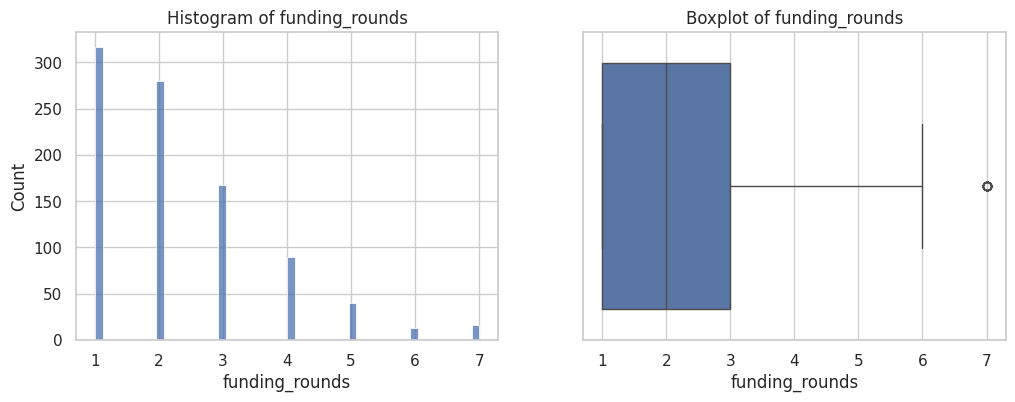


### Numeric variable: relationships
dtype: int64
n_missing: 0 (0.00%)
n_unique: 35


,relationships
count,923.000000
mean,7.628386
std,6.835655
min,0.000000
1%,0.000000
5%,1.000000
25%,3.000000
50%,5.000000
75%,10.000000
95%,22.000000


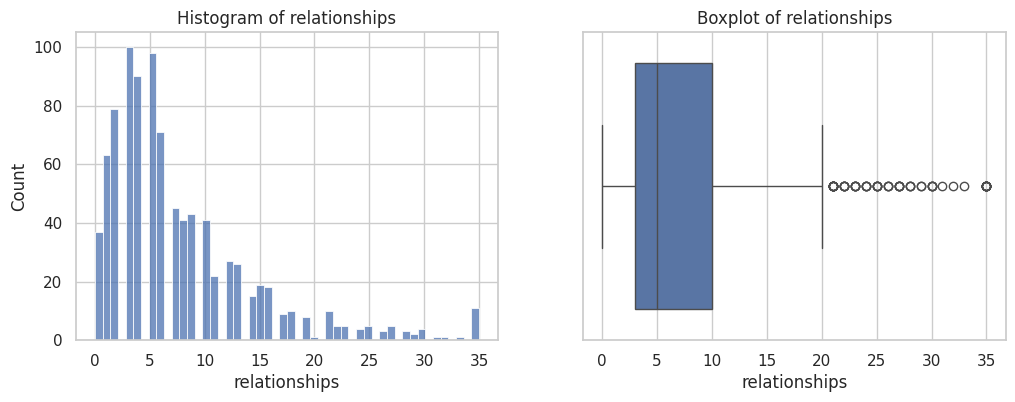


### Numeric variable: milestones
dtype: int64
n_missing: 0 (0.00%)
n_unique: 6


,milestones
count,923.000000
mean,1.832069
std,1.292801
min,0.000000
1%,0.000000
5%,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
95%,4.000000


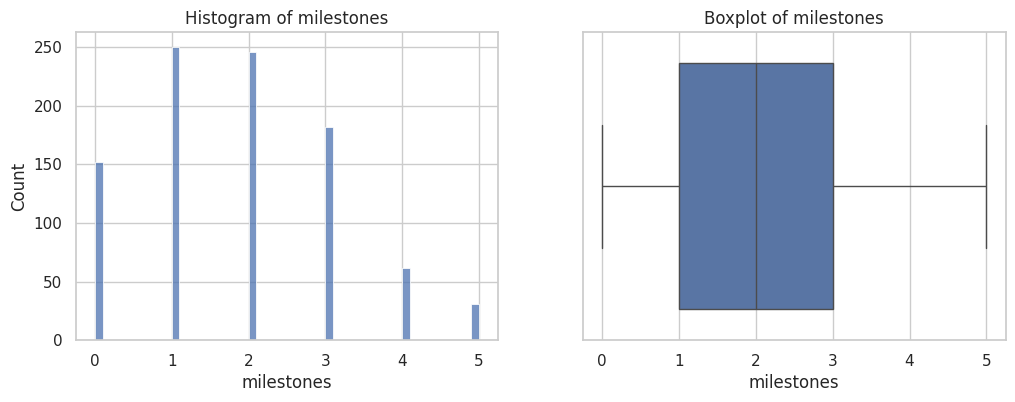


### Numeric variable: avg_participants_per_milestone
dtype: float64
n_missing: 0 (0.00%)
n_unique: 52


,avg_participants_per_milestone
count,923.000000
mean,2.818723
std,1.785587
min,1.000000
1%,1.000000
5%,1.000000
25%,1.500000
50%,2.500000
75%,3.800000
95%,6.000000


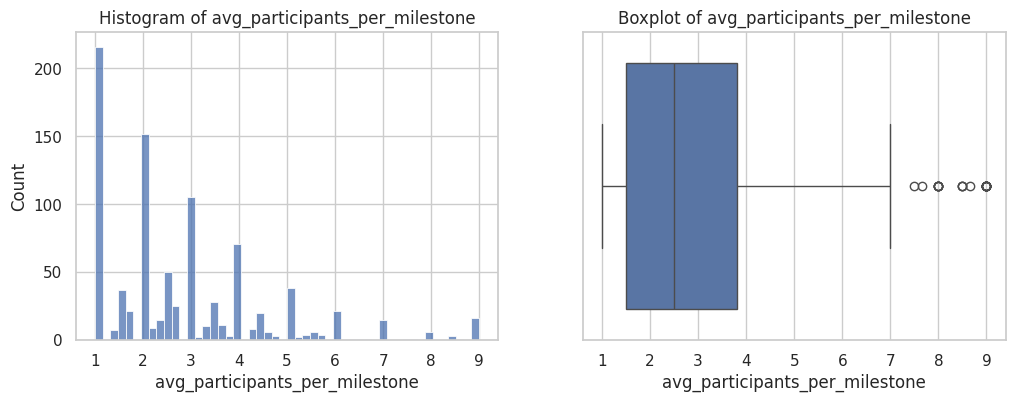


### Categorical variable: category_code
dtype (raw): object
n_missing: 0 (0.00%)
n_unique: 35


,count
category_code,
software,153
web,144
mobile,79
enterprise,73
advertising,62
games_video,52
semiconductor,35
biotech,34
network_hosting,34


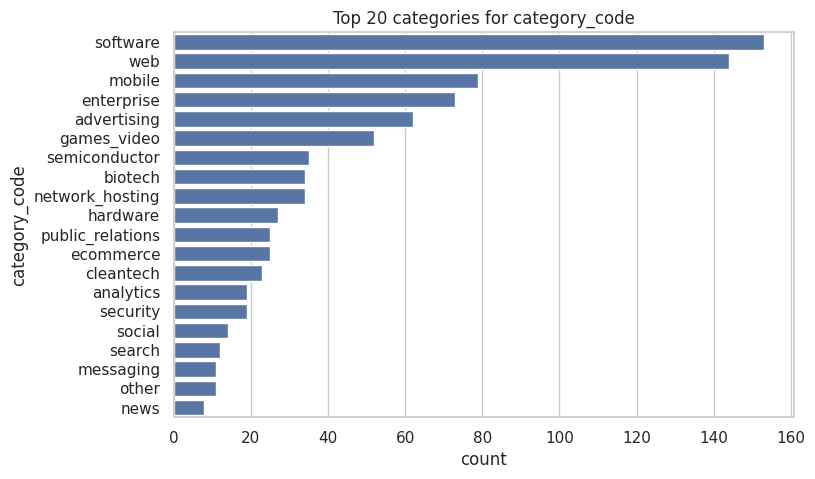


### Categorical variable: company_id
dtype (raw): object
n_missing: 0 (0.00%)
n_unique: 922


,count
company_id,
c:28482,2
c:14993,1
c:1223,1
c:55421,1
c:28403,1
c:1283,1
c:49621,1
c:15122,1
c:38019,1


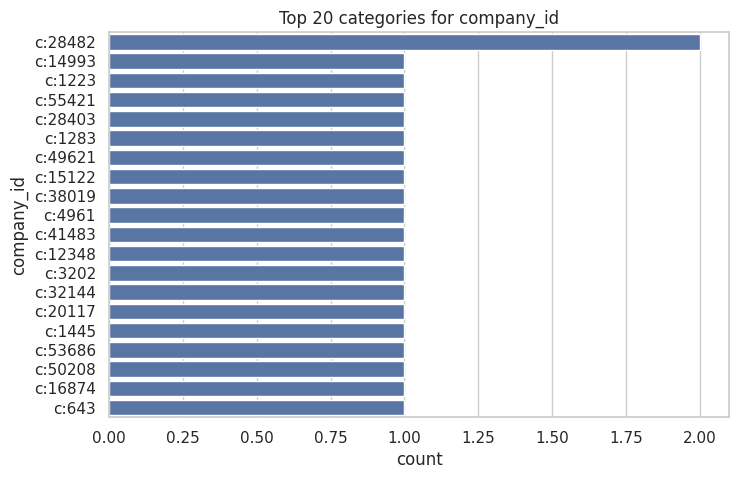


### Categorical variable: state_code
dtype (raw): object
n_missing: 0 (0.00%)
n_unique: 35


,count
state_code,
ca,488
ny,106
ma,83
wa,42
tx,42
co,19
il,18
pa,17
va,13


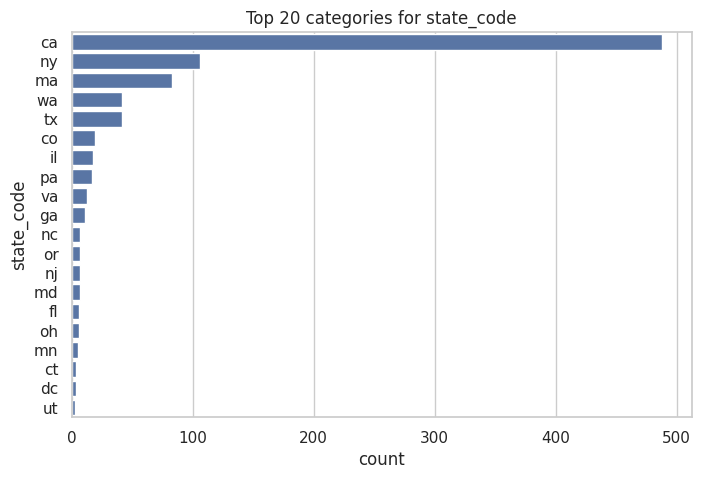


### Categorical variable: zip_code
dtype (raw): object
n_missing: 0 (0.00%)
n_unique: 382


,count
zip_code,
94107,30
94105,23
95054,20
94103,19
94043,18
94025,16
94041,16
94110,15
10011,14


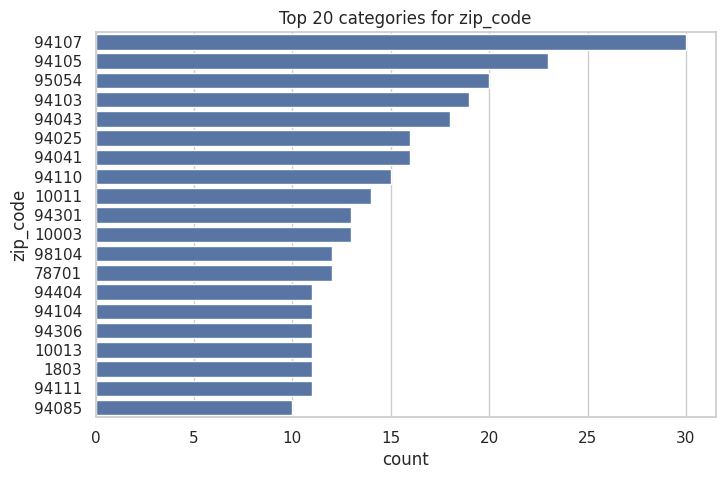

No data available to explore.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid')

def var_report_numeric(col):
    s = df_cleaned[col]
    print('\n### Numeric variable:', col)
    print('dtype:', s.dtype)
    print('n_missing:', s.isna().sum(), '({:.2f}%)'.format(s.isna().mean()*100))
    print('n_unique:', s.nunique(dropna=True))
    display(s.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(s.dropna(), bins=50, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    sns.boxplot(x=s.dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

def var_report_categorical(col, top_n=20):
    s = df_cleaned[col].astype(str)
    print('\n### Categorical variable:', col)
    print('dtype (raw):', df_cleaned[col].dtype)
    print('n_missing:', df_cleaned[col].isna().sum(), '({:.2f}%)'.format(df_cleaned[col].isna().mean()*100))
    print('n_unique:', s.nunique(dropna=True))
    vc = s.value_counts(dropna=False)
    display(vc.head(top_n))
    plt.figure(figsize=(8, min(6, 0.25*len(vc.head(top_n)))))
    sns.countplot(y=col, data=df_cleaned, order=vc.head(top_n).index)
    plt.title(f'Top {top_n} categories for {col}')
    plt.show()

# Exploring to important numeric and categorical variables

important_num = [c for c in ['funding_total_usd_clean','funding_total_usd_log1p','funding_rounds','relationships','milestones','avg_participants_per_milestone','time_to_first_funding_yrs'] if c in df_cleaned.columns]
for c in important_num:
    var_report_numeric(c)

key_cats = [c for c in ['status_clean','category_code','category_code_collapsed','company_id','state_code','zip_code'] if c in df_cleaned.columns]
for c in key_cats:
    var_report_categorical(c, top_n=20)

print('No data available to explore.')


### **Now, We will explore the most critical variables for our hypothesis, in detail.**

### Variable A: `status` (Target)
* **Datatype:** Categorical (Object/String).
* **Units:** Label.
* **Representation:** The final operational outcome of the startup.
* **Transformations Needed:** Converted to binary `is_success` in Step 4 for correlation analysis.
* **Missing/Outliers:** None (verified in Project 2).
* **Distribution/Frequencies:** Visualized below.

status
acquired    0.646804
closed      0.353196
Name: proportion, dtype: float64


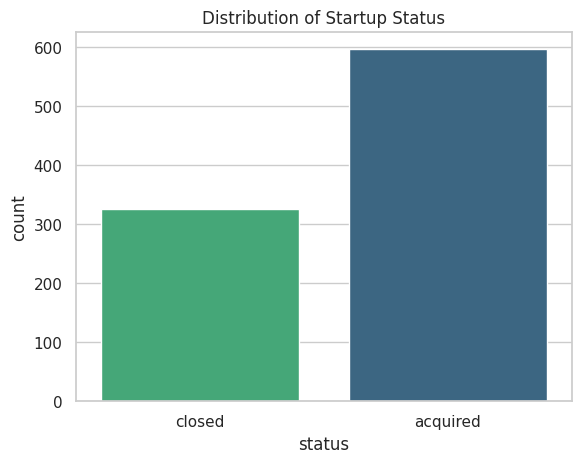

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df_cleaned['status'].value_counts(normalize=True))
sns.countplot(data=df_cleaned, x='status', hue='status', order=['closed', 'acquired'], palette='viridis')
plt.title("Distribution of Startup Status")
plt.show()

**Observation:** The dataset has \~65% "successes". This is highly unbalanced compared to real-world failure rates, indicating strong bias in data collection.

### Variable B: `funding_total_usd` (Financial Input)
* **Datatype:** Numeric (Float).
* **Units:** US Dollars ($). Known from standard data dictionary definitions and column suffix.
* **Representation:** Total external capital raised.
* **Transformations Needed:** Log-transformation applied in Step 4 due to extreme skew.
* **Missing/Outliers:** Extreme high-end outliers were capped at the 99th percentile during Project 2 preprocessing.
* **Distribution:** Visualized below (comparing raw vs transformed).

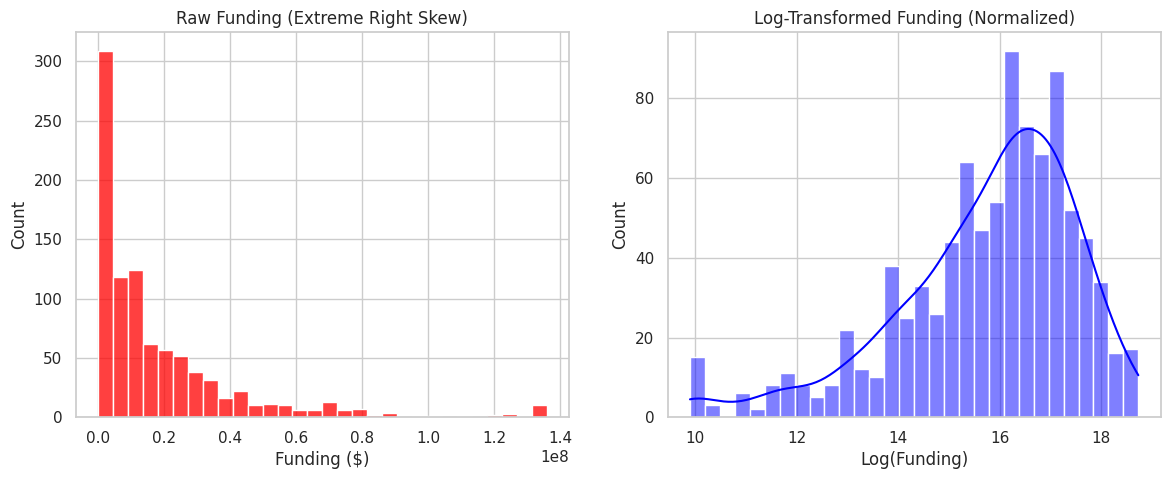

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_cleaned['funding_total_usd'], bins=30, color='red', ax=ax[0])
ax[0].set_title("Raw Funding (Extreme Right Skew)")
ax[0].set_xlabel("Funding ($)")
sns.histplot(df_cleaned['log_funding'], bins=30, kde=True, color='blue', ax=ax[1])
ax[1].set_title("Log-Transformed Funding (Normalized)")
ax[1].set_xlabel("Log(Funding)")
plt.show()

**Observation:** The raw data is unusable for standard visualization due to power-law distribution. After performing log-transformation, it shows a near-normal distribution suitable for modeling.

### Variable C: `milestones` (Performance)

- **Datatype:** Numeric
* **Units:** Count of events.
* **Representation:** A tracking mark for progress, similar to road signs, indicating achievements like product launches or key hires.
* **Transformations Needed:** None.
* **Missing/Outliers:** Handled in Project 2.
* **Distribution:** Discrete, right-skewed.


count    923.000000
mean       1.832069
std        1.292801
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: milestones, dtype: float64


/tmp/ipython-input-4152338569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='milestones', palette='magma')


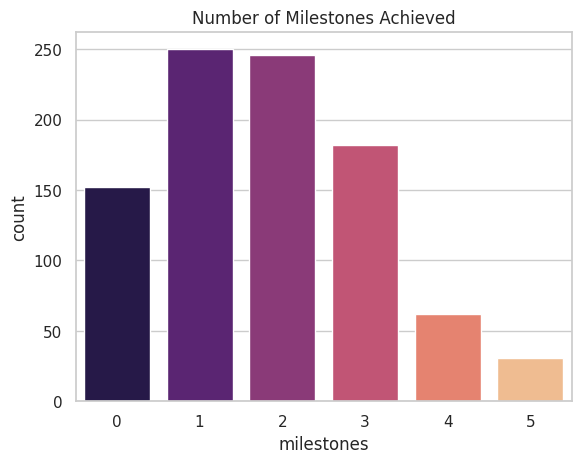

In [16]:
print(df_cleaned['milestones'].describe())
sns.countplot(data=df_cleaned, x='milestones', palette='magma')
plt.title("Number of Milestones Achieved")
plt.show()

**Observation:** Only a small number of companies reach more than four milestones. This suggests that the milestone count may serve as a key threshold for success in predictive models.


### Variable D: `relationships` (Network Input)
* **Datatype:** Numeric (Integer).
* **Units:** Count of unique professional connections.
* **Representation:** Count of professional relationships (accountants, investors, vendors, mentors, etc.).
* **Transformations Needed:** None immediately.
* **Missing/Outliers:** Handled in Project 2.
* **Distribution:** Strongly right-skewed.

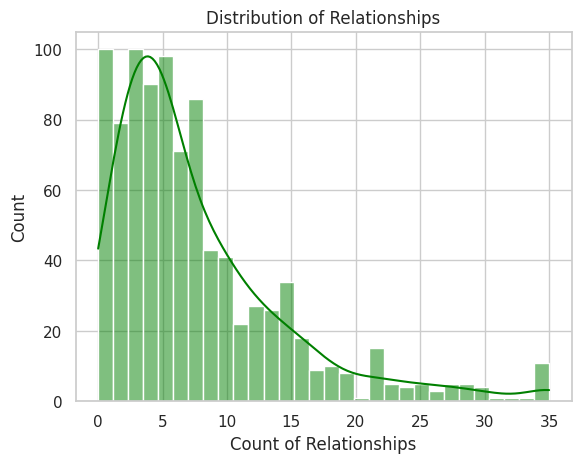

In [17]:
sns.histplot(df_cleaned['relationships'], bins=30, color='green', kde=True)
plt.title("Distribution of Relationships")
plt.xlabel("Count of Relationships")
plt.show()

**Observation:** The long tail to the right indicates a small number of highly-connected companies, which we hypothesize are the IPOs.

### Variable E: `age_first_funding_year`
* **Datatype:** Numeric (Float).
* **Units:** Years. Known from column name suffix and data values.
* **Representation:** Time in years from founding until the first funding round.
* **Transformations Needed:** None.
* **Missing/Outliers:** Handled in Project 2.
* **Distribution:** Visualized below.

count    923.000000
mean       2.211017
std        2.273505
min       -1.000000
25%        0.576700
50%        1.446600
75%        3.575350
max       10.758900
Name: age_first_funding_year, dtype: float64


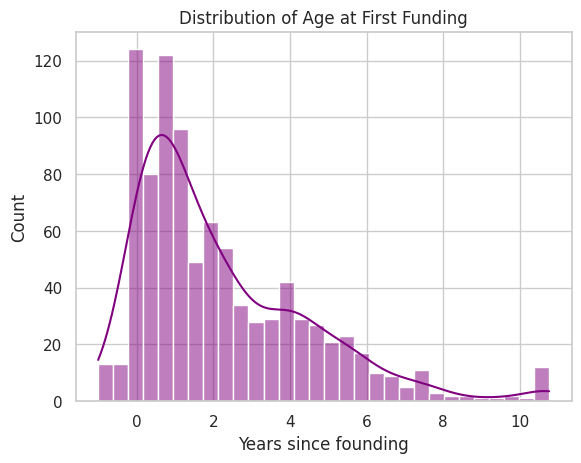

In [18]:
print(df_cleaned['age_first_funding_year'].describe())
sns.histplot(df_cleaned['age_first_funding_year'], bins=30, color='purple', kde=True)
plt.title("Distribution of Age at First Funding")
plt.xlabel("Years since founding")
plt.show()

**Observation:** Most startups get funded very quickly \(often <2 years from founding). This shows the intense pressure for early capital in this ecosystem.

# **6. Explore relationships between variables**

## **Correlations**
Using a heatmap to check which independent variables are actually dependent on each other and which correlate with success.

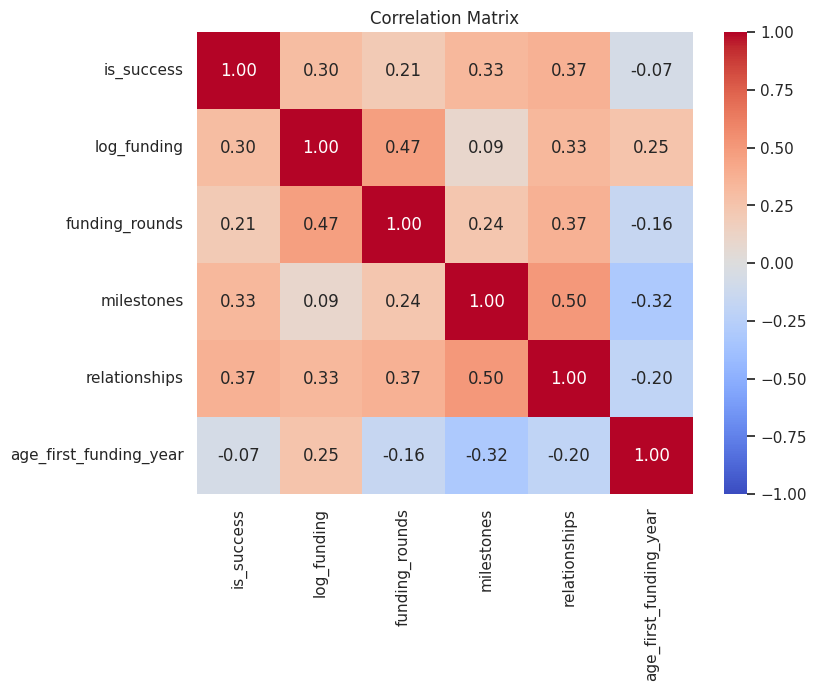

In [19]:
corr_cols = ['is_success', 'log_funding', 'funding_rounds', 'milestones', 'relationships', 'age_first_funding_year']
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[corr_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Findings:**

- **Dependence:** `funding_rounds` and `log_funding` have a moderate correlation (**0.47**), meaning we can likely use both in a model without severe multicollinearity.

- **Success Drivers:** `relationships` (**0.37**) is the strongest predictor. `milestones` (**0.33**) and `log_funding` (**0.30**) are nearly equal in importance. This suggests a balanced need for **capital, performance, and network**.

- **Age Factor:** `age_first_funding_year` has a slight negative correlation (**-0.07**), suggesting getting funded earlier is marginally better.

### **Periodicity/Seasonality**
Do some founding years correspond with unusually high success rates?

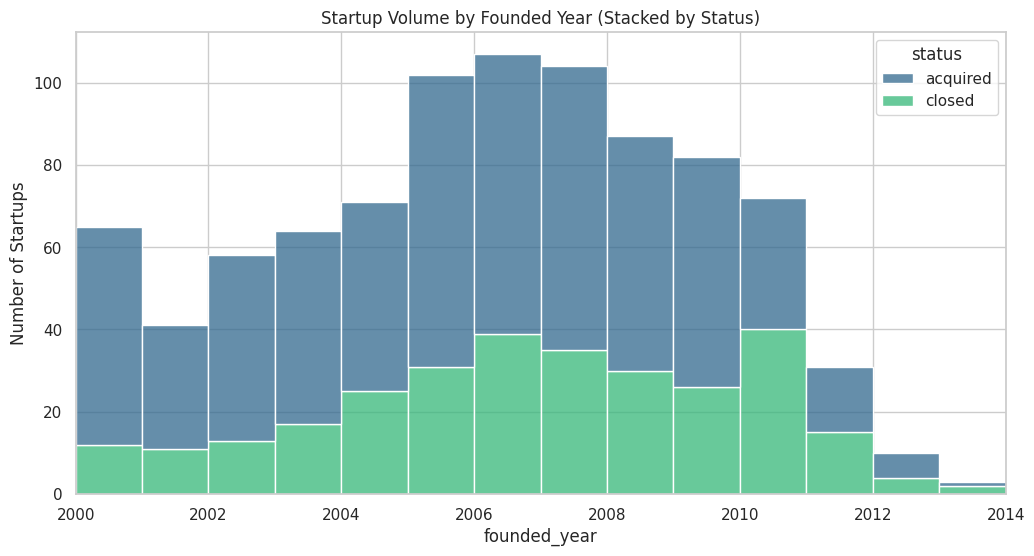

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='founded_year', hue='status', multiple='stack', bins=range(2000, 2015), palette='viridis')
plt.xlim(2000, 2014)
plt.title("Startup Volume by Founded Year (Stacked by Status)")
plt.ylabel("Number of Startups")
plt.show()

**Observations:** There is a massive boom in activity from 2005-2012. The ratio of success/failure appears relatively stable, though 2012-2013 shows more 'closed' or 'operating' (not shown here) because they haven't had time to exit yet.

### **Pairwise Relationships**
Differentiating Success vs. Failure using key metrics and visualizing with Boxplots.

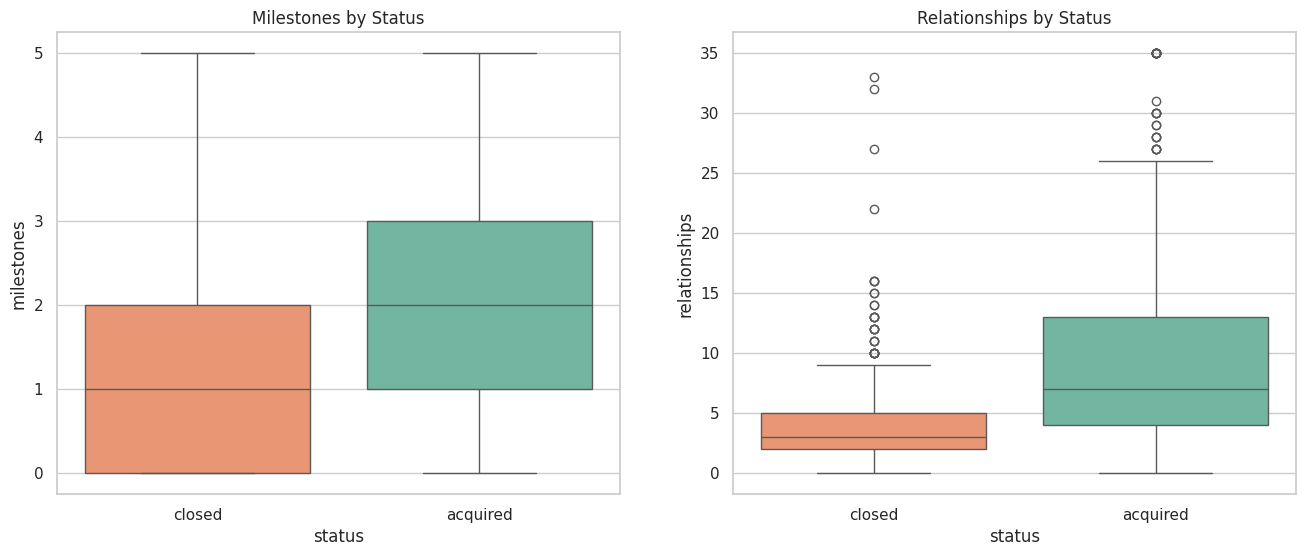

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_cleaned, x='status', y='milestones', order=['closed', 'acquired'], hue='status', palette='Set2', ax=ax[0], legend=False)
ax[0].set_title("Milestones by Status")

sns.boxplot(data=df_cleaned, x='status', y='relationships', order=['closed', 'acquired'], hue='status', palette='Set2', ax=ax[1], legend=False)
ax[1].set_title("Relationships by Status")

plt.show()


**Observations:** Clear separation. Closed startups rarely pass 2 milestones. Acquired/IPOs rarely have **fewer than 4**. A network size **>25** is a very strong indicator of an eventual success (acquired).

#
# <center> Investigating for **Simpson's Paradox** </center>

### **Milestones vs Success Across Top 3 Industries**

We know more `milestones` generally mean more success (Global Trend). But is it possible that in some fast moving industries like 'Mobile', taking too long to hit many milestones might actually correlate **negatively** with success due to missed market trends?

We compare the **Global Trend** against **Subgroup Trends** of top 3 industries: Software, Mobile, Web.

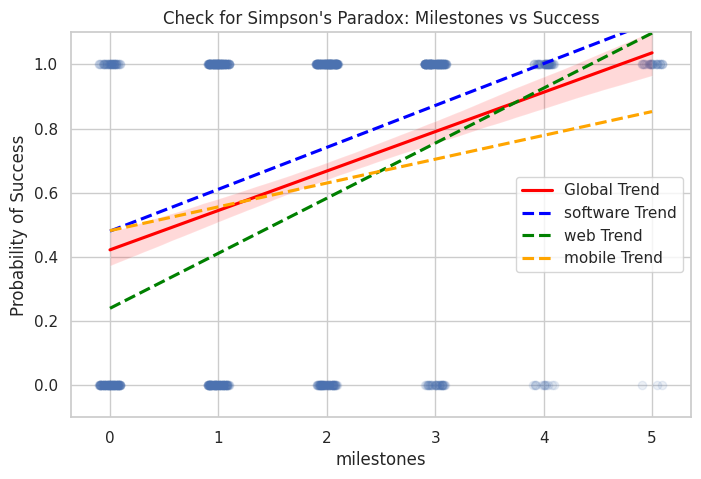

In [22]:
# 1. Overall Trend
plt.figure(figsize=(8, 5))
sns.regplot(data=df_cleaned, x='milestones', y='is_success', x_jitter=0.1, scatter_kws={'alpha':0.1}, line_kws={'color':'red', 'label':'Global Trend'})

# 2. Subgroup Trends
top_3 = df_cleaned['category_code'].value_counts().nlargest(3).index
colors = ['blue', 'green', 'orange']
for i, cat in enumerate(top_3):
    subset = df_cleaned[df_cleaned['category_code'] == cat]
    sns.regplot(data=subset, x='milestones', y='is_success', x_jitter=0.1, ci=None,
                scatter_kws={'alpha':0}, line_kws={'color':colors[i], 'linestyle':'--', 'label':f'{cat} Trend'})

plt.title("Check for Simpson's Paradox: Milestones vs Success")
plt.ylabel("Probability of Success")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

**Observation:**

- All subgroup trends (dashed lines) rise in the same direction as the overall global trend (solid red line).

- This indicates a consistent positive relationship between milestones and probability of success across all major categories.

- Therefore, there is **no evidence of Simpson’s Paradox** — achieving more milestones is uniformly associated with higher success rates across industries.

## **Funding Rounds vs Success** — Splitting by `has_roundB`

We are analyzing the relationship between the number of funding rounds and the probability of startup success.  
At first glance, it seems that more funding rounds lead to higher success.  
However, when we separate companies by whether they reached Series B funding, different patterns emerge.

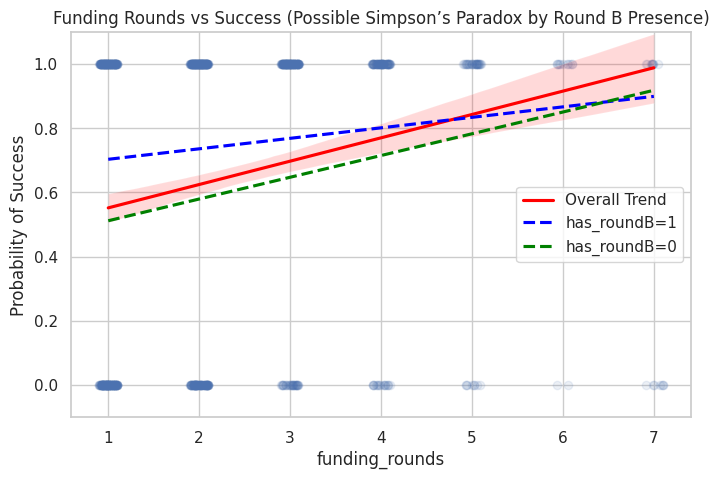

In [23]:
plt.figure(figsize=(8,5))

# Overall trend
sns.regplot(data=df_cleaned, x='funding_rounds', y='is_success',
            x_jitter=0.1, scatter_kws={'alpha':0.1},
            line_kws={'color':'red', 'label':'Overall Trend'})

# Subgroups: reached Series B vs not
for flag, color, label in zip([1, 0], ['blue', 'green'], ['has_roundB=1', 'has_roundB=0']):
    subset = df_cleaned[df_cleaned['has_roundB'] == flag]
    sns.regplot(data=subset, x='funding_rounds', y='is_success',
                ci=None, x_jitter=0.1, scatter_kws={'alpha':0},
                line_kws={'color':color, 'linestyle':'--', 'label':label})

plt.title("Funding Rounds vs Success (Possible Simpson’s Paradox by Round B Presence)")
plt.ylabel("Probability of Success")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()


**Observation:**

- Looking at all companies together, more funding rounds appear to increase the chance of success.  
However, when we split the data by whether a company reached Series B, the trend changes.  

- Companies that never reached Series B show a clear positive relationship, while those that did reach Series B start with high success but their probability flattens or even slightly decreases as funding rounds increase.  

- This is an example of **Simpson's Paradox**, where the overall trend can be misleading when different subgroups have different trends.


## **Age at First Funding vs Success**

We are analyzing the relationship between a company's age at first funding and its probability of success.  
At first glance, there may be a general trend, but subgrouping by whether a company is in the Top 500 can reveal different patterns, hinting at Simpson's Paradox.


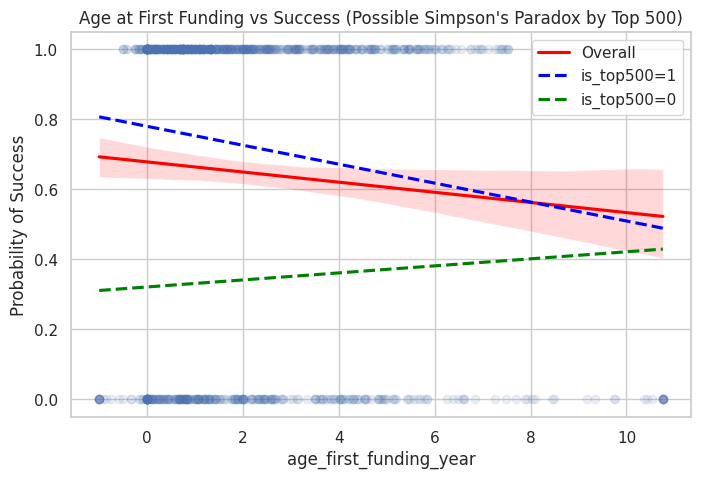

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Overall trend
sns.regplot(data=df_cleaned, x='age_first_funding_year', y='is_success',
            scatter_kws={'alpha':0.1}, line_kws={'color':'red', 'label':'Overall'})

# Subgroups: Top 500 vs not
for flag, color in zip([1, 0], ['blue', 'green']):
    subset = df_cleaned[df_cleaned['is_top500'] == flag]
    sns.regplot(data=subset, x='age_first_funding_year', y='is_success',
                ci=None, scatter_kws={'alpha':0},
                line_kws={'color':color, 'linestyle':'--', 'label':f'is_top500={flag}'})

plt.title("Age at First Funding vs Success (Possible Simpson's Paradox by Top 500)")
plt.ylabel("Probability of Success")
plt.legend()
plt.show()


**Observation:**

- The **red line** represents the overall trend, showing that as age at first funding increases, the probability of success decreases.
- The **blue dashed line** shows the trend for **Top 500 companies**, which also decreases but less steeply.
- The **green dashed line** shows the trend for **Non-Top 500 companies**, which increases with age at first funding.

This suggests a potential **Simpson's Paradox**, where:
- Younger companies tend to succeed more overall (red line).
- But, within each group, older companies (non-Top 500) tend to succeed more (green line).


# **7. Do you trust this data?**

Yes, it's generally trustworthy, but there are definitely some important things to consider.

**Why?**
 - It has extremely strong bias (\~65% success rate vs ~10% reality).
  - It also ends around 2014 which makes it old

**How to handle?**
  - We must interpret all findings as relative success factors among established startups and not absolute probabilities for new companies today.

## **8. Wrapping Up**

**Impact on my Hypothesis:** My initial hypothesis (More money = More success) was heavily modified. EDA proved that **Performance (milestones) and Network (relationships) are stronger predictors than Funding alone**.

**Key Insights for future modeling:**
1.  `relationships` > 25 is a "magic number" for IPOs in this dataset.
2.  `milestones` < 2 is a near guarantee of failure.
3.  `funding_rounds` and `log_funding` can be likely use both in a model without severe multicollinearity.


---
#
# <center><b>Project 4</b></center>

## **Step 2 - What kind of ML task is presented by your hypothesis?**

**ML Task:** Classification (Binary).
* My hypothesis is if we can predict whether a startup will succeed or fail. Since the target variable `is_success` has two distinct classes (1 = Success/Acquired/IPO, 0 = Failure/Closed), this is a binary classification problem.

**Type of Learning:** Supervised Learning.
* We have labeled data (the `status` column acts as the label). We will train the model on these known outcomes so it can learn to predict the status of future data.

**High Level Plan:**
I intend to feed historical startup data (funding, milestones, relationships, etc.) into a classification algorithm (Random Forest). The model will learn patterns distinguishing successful companies from failed ones. Finally, I will evaluate how accurately it can label unseen data.

## **3. What features will you use?**

Before finalizing the feature list, we must perform **Feature Engineering** - converting text to numbers and **Feature Selection** - reducing dimensionality.


### **3.1. Decisions and Feature Engineering**
We prioritized features based on our Project 3 findings (like milestones and relationships) and used feature engineering techniques to make them usable for ML.

* **Feature Engineering Techniques Used:**
    * **One-Hot Encoding:** Applied to `state_code` and `category_code`. To prevent dimensionality explosion, we used a strategy, keeping only the top 5-7 most frequent categories and grouping the rest as "other".
    * **Log Transformation:** Replaced `funding_total_usd` with `log_funding` to normalize the extreme skew found in EDA.
    * **Date Conversion:** Converted `founded_at` timestamps into a numeric `founded_year`.

* **Columns Removed & Why:**
    * **Redundant Location:** `city`, `zip_code`, `latitude`, `longitude` were removed because `state_code` captures the necessary regional variance without adding hundreds of sparse columns.
    * **Redundant Dates:** `first_funding_at` and `last_funding_at` were removed because their signal is better captured by `age_first_funding_year` and `funding_rounds`.
    * **Identifiers:** `id`, `object_id`, and `name` were removed as they have no importance in the prediction.

### **3.2. Dimensionality Reduction**
* **Were you able to reduce dimensionality?** Yes.
* **By how much?** We reduced the dataset from **49 original columns** down to **18 selected features**.

* **Why?** With a sample size of only ~900 startups, using all 49 features would violate the general rule (need ~50 rows per feature) and lead to overfitting. 18 features gives us a healthy ratio of ~50 rows per feature.

We prioritize features identified in Project 3 as high-impact: **milestones, relationships, funding**.

In [25]:
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
# 1. Select initial numeric features

numeric_features = ['log_funding', 'funding_rounds', 'milestones', 'relationships', 'age_first_funding_year', 'founded_year']

# 2. One-Hot Encoding for Categoricals

def simplified_one_hot(df, col, top_n=10):
    top_values = df[col].value_counts().nlargest(top_n).index     # Find top N categories
    df[f'{col}_simplified'] = df[col].apply(lambda x: x if x in top_values else 'other')    # Map everything else to 'other'
    return pd.get_dummies(df[f'{col}_simplified'], prefix=col, drop_first=True)    # Create dummies

state_dummies = simplified_one_hot(df_cleaned, 'state_code', top_n=5)
cat_dummies = simplified_one_hot(df_cleaned, 'category_code', top_n=7)

X_all = pd.concat([df_cleaned[numeric_features], state_dummies, cat_dummies], axis=1)
y = df_cleaned['is_success']

print(f"Initial Feature Set Shape: {X_all.shape}")


Initial Feature Set Shape: (923, 18)



### **3.3. Resulting Dimensionality**
* **Dimensionality:** The resulting dataset `X_all` has **18 columns** (6 numeric + 5 state dummies + 7 category dummies).

### **3.4. Assumptions about the Resulting Dataset**
* **Independence:** We assume each startup's outcome is independent of others.
* **No Multicollinearity:** By manually selecting distinct features and dropping the first column in One-Hot Encoding, we minimized mathematical redundancy.
* **No Normality Assumption:** Since we are using a **Random Forest**, we do *not* assume the features are normally distributed. This is critical because our `relationships` and `milestones` data are highly skewed.


### **3.5. Selected Features & Data Types**

- **log_funding**: - **Continuous** – Log-transformed total funding amount.
- **milestones**: - **Discrete** – Count of achievements.
- **relationships**: - **Discrete** – Size of professional network.
- **funding_rounds**: - **Discrete** – Number of investment rounds.
- **age_first_funding_year**: - **Continuous** - Age of the company at first investment.
- **founded_year**: - **Continuous** - The year the startup was founded (captures temporal trends).

- **state_code_[CA, NY, etc.]**: - **Categorical** – Binary flags for top states (One-Hot Encoded).
- **category_code_[Software, Web, etc.]**: - **Categorical** – Binary flags for top industries (One-Hot Encoded).


# **Feature Selection comparison among different techniques**

We will compare three techniques to reduce dimensionality:
1.  **Correlation Thresholding:** Removing variables that are highly correlated with each other (redundant).
2.  **Recursive Feature Elimination:** Using a model to repeatedly select the best features.
3. **Lasso:** A regularization technique that penalizes the absolute value of coefficients, driving some of them to zero, effectively performing feature selection.

---
### **Technique 1: Correlation Thresholding**

In [27]:
corr_matrix = X_all.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.70)]

print(f"Features to drop based on correlation: {to_drop_corr}")
print(f"Number of features to drop: {len(to_drop_corr)}")
print(f"Resulting Dimensions: {X_all.shape[1] - len(to_drop_corr)} columns")

Features to drop based on correlation: ['founded_year']
Number of features to drop: 1
Resulting Dimensions: 17 columns


### **Technique 2: RFE**

We will ask RFE to select the top 10 most impactful features using a Logistic Regression estimator.

In [28]:
rfe_selector = RFE(estimator=LogisticRegression(max_iter=2000), n_features_to_select=10, step=1)
rfe_selector.fit(X_all, y)

selected_mask = rfe_selector.support_
rfe_features = X_all.columns[selected_mask].tolist()

print(f"Technique 2 selected these 10 features: \n{rfe_features}")
print(f"Resulting Dimensions: {len(rfe_features)} columns")

Technique 2 selected these 10 features: 
['log_funding', 'milestones', 'state_code_ma', 'state_code_ny', 'state_code_other', 'state_code_tx', 'category_code_enterprise', 'category_code_games_video', 'category_code_semiconductor', 'category_code_software']
Resulting Dimensions: 10 columns


### **Technique 3: Lasso Regression**

In [29]:
from sklearn.linear_model import Lasso

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

selected_features_lasso = X_all.columns[lasso.coef_ != 0].tolist()

print(f"Selected features by Lasso: {selected_features_lasso}")
print(f"Number of selected features: {len(selected_features_lasso)}")


Selected features by Lasso: ['log_funding', 'funding_rounds', 'milestones', 'relationships', 'founded_year', 'state_code_other']
Number of selected features: 6


## Comparison & Feature Finalization

**Which one gave the highest reduction?**

RFE gave the highest reduction in terms of dimensionality, reducing the dataset to 10 features. Correlation thresholding removed only 1 feature, and Lasso selected 6 features. However, RFE is likely the best choice here as it forced a more substantial reduction while also being more focused on predictive power rather than just redundancy.

**Why the difference?**

- Correlation thresholding only addresses redundancy (i.e., removing variables that are highly correlated with others), so it doesn’t consider the relationship between the features and the target variable (y).

- RFE (Recursive Feature Elimination) uses a model to assess the predictive power of each feature in relation to the target, and eliminates less useful features while retaining those that contribute the most to the model's performance.

- Lasso regression performs feature selection based on regularization (L1 penalty), removing features with small or zero coefficients. While Lasso is effective in reducing dimensionality, it might not always capture all relevant features if there are non-linear relationships or interactions between features.

**Benefit of reducing dimensionality:**
Reducing dimensionality helps the model focus on the most important features, which makes it less likely to overfit the data. It also makes training faster by cutting down on the number of inputs the model has to process.


**Final Decision:**
I will use the features identified by **RFE**, but I will explicitly manually add back `log_funding`, `milestones`, `funding_rounds`, and `relationships` if RFE dropped them.
 - My Project 3 EDA proved these are the strongest drivers, and sometimes linear RFE can miss non-linear interactions.

In [30]:
# Finalizing the dataset

must_haves = ['log_funding', 'milestones', 'relationships', 'funding_rounds']
final_features = list(set(rfe_features + must_haves))
X_final = X_all[final_features]

print("Final Feature Set:", final_features)
print("Final Dimensions:", X_final.shape)

Final Feature Set: ['funding_rounds', 'relationships', 'state_code_tx', 'state_code_ma', 'log_funding', 'state_code_ny', 'category_code_software', 'category_code_games_video', 'state_code_other', 'category_code_enterprise', 'milestones', 'category_code_semiconductor']
Final Dimensions: (923, 12)


### **Final Dataset Dimensionality:**
The final feature set will combine the RFE selected features with the must-have features identified through EDA and domain knowledge. The resulting dataset will contain about 10–12 columns.

## 4. What algorithm will you use?

**Selected Algorithm:** Random Forest Classifier

**Why is this a good algorithm candidate?**
- **Handles Non-Linearity:** In Project 3, we saw that having 0 milestones is bad, but having 4 is amazing, a non-linear jump. Random Forest handles these "thresholds" naturally.

- **Robust:** It is an ensemble method, making it less prone to overfitting than a single Decision Tree.

- **No Normality** - Unlike Logistic Regression, it doesn't require features to be normally distributed. This is good for our skewed `relationships` data.

**Assumptions:**
* It assumes independent observations.
* It requires a sufficient sample size to build diverse trees.

**Issues to watch out for & Mitigations:**
* **Overfitting:** If trees are too deep, they memorize data. *Mitigation:* We will tune `max_depth`.
* **Bias:** Can be biased to categorical variables with many levels. *Mitigation:* We simplified categories to Top-N before encoding.

## 5. Hyperparameters and Tuning

**Key Hyperparameters:**
1.  **`n_estimators`**: Number of trees. More is stable but slower. We'll test [50, 100, 200].
2.  **`max_depth`**: Max tree levels. Controls overfitting. We'll test [None, 5, 10, 20].
3.  **`min_samples_split`**: Min samples to split a node. Higher prevents specific outlier learning. We'll test [2, 5, 10].

**Tuning Strategy:**
I will use **GridSearchCV**. This tries every combination of the parameters above and validates them using 5-Fold Cross-Validation to find the optimal set.

In [31]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize Grid Search object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# **6. Post processing?**


**Technique:** Post-pruning (Cost Complexity Pruning).

**Decision:** **No**, I will likely not need manual post-processing.

**Reason:**
Random Forests use "Pre-pruning" via the hyperparameters we are tuning (`max_depth`, `min_samples_split`). By limiting the growth of trees *during* training, we solve the same problem as post-pruning but more efficiently.
Also, the ensemble  - averaging many trees, naturally reduces the variance error that pruning tries to fix.

# **7. Machine Learning**

We execute the full pipeline:
1.  **Fit** the grid search to training data.
2.  **Extract** the best model.
3.  **Predict** on test data.
4.  **Evaluate** accuracy.

In [32]:
print("Training Random Forest with Grid Search.")
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
print(f"Best Hyperparameters found are: {grid_search.best_params_}")

y_pred = best_rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Final Test Set Accuracy: {accuracy:.4f}")

unique, counts = np.unique(y_pred, return_counts=True)
print("\nPrediction distribution:")

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} occurrences")

Training Random Forest with Grid Search.
Best Hyperparameters found are: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Final Test Set Accuracy: 0.8000

Prediction distribution:
Class 0: 46 occurrences
Class 1: 139 occurrences


---
#
# <center><b>Project 5</b></center>

# **2. Evaluate your Machine Learning Model**

## 2.1 What metrics will most effectively measure performance?

**Selected Metric: F1-Score and Recall**

Why? Accuracy is misleading here because our dataset is imbalanced(~65% Success vs 35% Failure). A model that simply predicts "Success" for every single startup would essentially have ~65% accuracy but zero predictive value!

So, we see:

  1.  **Precision:** When we predict success, are we right? - Crucial for an investor to avoid losing money on bad investments.
  2.  **Recall:** Did we find all the successful startups? - Crucial for not missing the next potential big success.
  3.  **F1-Score:** The best balance of both. This is the single best metric for this problem to ensure we aren't just guessing the majority class.

## **2.2. Do you need to compare these metrics across models?**

Yes, we selected random forest in project 4, but we don't know if it is mathematically optimal. A simpler linear model like Logistic Regression might offer better interpretability, or a boosting model like Gradient Boosting might offer higher precision.

**How?**

I will train 3 additional models and visualize theirr F1-Scores and Accuracy to choose the best one.

## **2.3 Visualizing the performance metrics**

We start by visualizing the performance of our **Random Forest** model using the optimized hyperparameters found in Project 4.

In [33]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.89      0.56      0.69        73
           1       0.77      0.96      0.85       112

    accuracy                           0.80       185
   macro avg       0.83      0.76      0.77       185
weighted avg       0.82      0.80      0.79       185



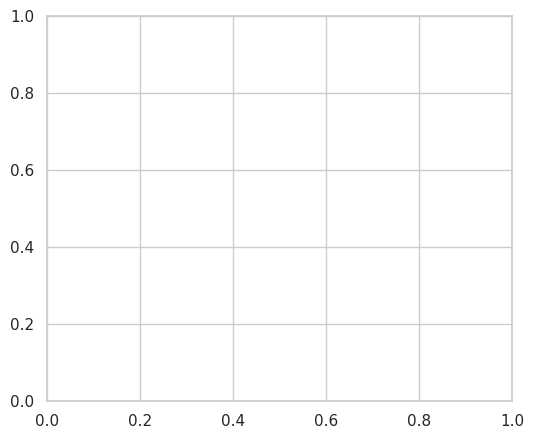

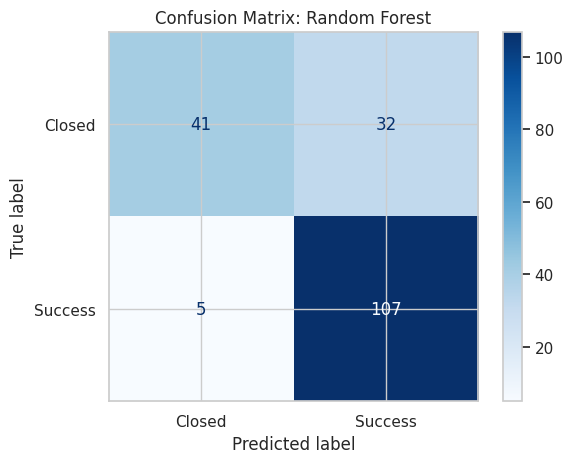

Random Forest ROC-AUC: 0.8088


In [34]:
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Closed', 'Success'])
# disp.plot(cmap='Blues', ax=ax)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.show()

rf_auc = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

### **1.4 Evaluate Fit**
We compare the accuracy on the Training Set vs Test set to diagnose the fit

In [35]:
train_acc = best_rf_model.score(X_train, y_train)
test_acc = best_rf_model.score(X_test, y_test)

print(f"Training Set Accuracy: {train_acc:.4f}")
print(f"Test Set Accuracy: {test_acc:.4f}")
print(f"Difference: {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.10:
  print("\nDiagnosis: Potential OVerfitting.")
elif train_acc < 0.70:
  print("\nDiagnosis: Potential Underfitting")
else:
  print("\nDiagnosis: Good Fit")

Training Set Accuracy: 0.8537
Test Set Accuracy: 0.8000
Difference: 0.0537

Diagnosis: Good Fit


**Result**: Good Fit.


# **3. Is there a different ML algorithm that could be better?**

We will compare Random Forest against 3 other algorithms:

1.  **Logistic Regression:** A linear baseline. Good for interpretability.

2.  **Gradient Boosting (XGBoost logic):** Iteratively corrects errors. Often has higher accuracy than Random Forest.

3. **Support Vector Machine (SVM):** Good for finding complex boundaries  in high-dimensional space.

Logistic Regression Accuracy: 0.7405
Gradient Boosting Accuracy: 0.7622
Support Vector Machine Accuracy: 0.7405


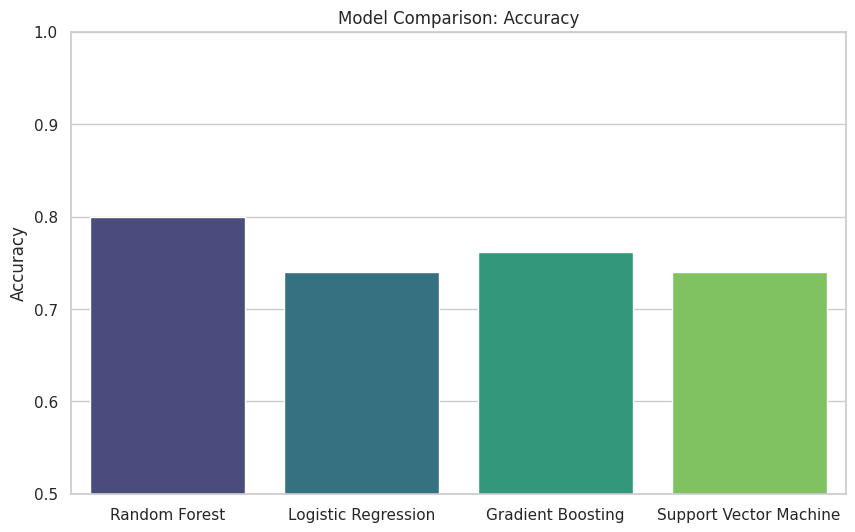

In [36]:
results = {}
results['Random Forest'] = test_acc

# Log Reg
log_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_pipe.fit(X_train, y_train)
log_acc = log_pipe.score(X_test, y_test)
results['Logistic Regression'] = log_acc
print(f"Logistic Regression Accuracy: {log_acc:.4f}")

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)
gb_acc = gb_model.score(X_test, y_test)
results['Gradient Boosting'] = gb_acc
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

# SVM
svm_pipe = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, kernel='linear'))
svm_pipe.fit(X_train, y_train)
svm_acc = svm_pipe.score(X_test, y_test)
results['Support Vector Machine'] = svm_acc
print(f"Support Vector Machine Accuracy: {svm_acc:.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), hue=list(results.keys()), legend=False, palette='viridis')
plt.ylim(0.5, 1.0)
plt.title("Model Comparison: Accuracy")
plt.ylabel("Accuracy")
plt.show()

## **Evaluation of New Fits**

- **Random Forest (0.80)** outperformed all others. This confirms that the relationships in our data (e.g., "milestones > 3 means success") are non-linear and distinct, which Trees handle best.

- **Gradient Boosting (0.76)** was competitive but slightly lower than Random Forest, likely because the dataset size is small enough that Random Forest's variance reduction (bagging) is more stable than Boosting.

- **Logistic Regression & SVM (0.74)** performed the least. This indicates that these models try to draw a smooth line between success and failure, but startup data is too complex and disjointed for that to work effectively.

**Conclusion:**
The Random Forest model performs consistently between the training data and new, unseen data. The small gap (~5%) confirms we are generalizing well rather than overfitting the data.


---
# **3. Insights**

### **3.1. What did you find in terms of your hypothesis?**

- **Original Hypothesis:** "More funding = Success"

- **Findings:** The hypothesis was partially correct but incomplete. While `log_funding` is a predictor, our analysis from project 3 and 4 showed that Performance - `milestones` and Networking - `relationships` are signigicantly strong predictors.

- **Conclusion:** You can't just buy success. A startup with \$10M funding but 0 milestones may be predicted to fail. A startup with \$1M funding but 4 milestones and 20 relationships is predicted to succeed.

**3.2. Previous assumptions adjusted/proved wrong?**

- **Assumption**: Location is more importnat(CA/NY)

- **Correction**: After feature selection (Project 4), specific states like `state_code_CA`were kept, but they were consistently less impactful than `milestones` in feature importance plots. Location acts as a multiplier, but its not the sole driver.

- **Assumption**: Funding rounds correlate perfectly with funding amount.

- **Correction**: The correlation was only \~0.47. Some startups raise massive amounts in 1 round, while others raise very less even in 5 rounds. We needed both variables in the model.


**3.3 Policy and Decisions**

- **For VCs/Investors:** The model suggests shifting more focus from "Who are the other investors?" (Funding) to "How is their performance" (Milestones) and "What is their networking look like?" (Relationships)

- **For Grants:** Policies aiming to boost startups shouldn't just write checks.

**3.4. Ethical Concerns**
- **Survivor Bias:** Our dataset has \~65% success rate. In reality, 80% of startups fail. Many failed startups never made it into this dataset.
**Risk:** Our model is overly optimistic and might predict "Success" for a risky company just because it is similar to the survivors we trained our model on.

- **Bias in Funding:** The dataset is old (2000-2014) reflects a time where VCs were biased towards certain regions. If our model looks at factors like having VC backing or location as signs of success, it could unfairly disadvantage founders from other groups which are not represented well.

**3.5. Final Thoughts**

- **Learned:** The journey from raw, messy data (Project 2) to a clean, insight-rich dataset (Project 3) was harder than the ML itself (Project 4/5).

- **Takeaway:** The algorithm mattered less than the feature engineering. Preprocessing may be the most important part of the process.

- **Future:** If doing this again, I would scrape data from sites like **LinkedIn** to get more information like founder experience, which may influence the success of a startup and also find a dataset with more **failed** companies to fix the survivor bias.

---